## ***Librerias***

In [1]:
#MANEJO Y MANIPULACIÓN DE CONJUNTO DE DATOS
import pandas as pd
import numpy as np

#GRAFICOS
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

#SEPARACIÓN DE DATOS (DATA SPLIT)
from sklearn.model_selection import train_test_split

#MODELO: AJUSTE Y EVALUACIÓN
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, recall_score, precision_score, accuracy_score

In [2]:
dataset = pd.read_csv('data_credito.csv', header = 0)
dataset.head()

,Ingreso_mensual,Tipo_ingreso,Edad,Ratio_deuda_ingreso,Historial_mora,Monto_credito,Monto_aprobado,Tasa_interes,Estado_credito
0,3497,Independiente,28,65,Con mora,17113,0,0,False
1,2862,Independiente,63,52,Sin mora,6708,6708,20,True
2,3648,Empleado,40,79,Sin mora,11117,11117,11,True
3,4523,Empleado,53,33,Sin mora,28244,28244,14,True
4,2766,Independiente,46,76,Sin mora,17345,0,0,False


In [3]:
print(f'Filas (Observaciones): {dataset.shape[0]} \nColumnas (variables): {dataset.shape[1]}')

Filas (Observaciones): 1000 
Columnas (variables): 9


## ***Analisis exploratorio de datos (EDA)***

<Figure size 640x480 with 0 Axes>

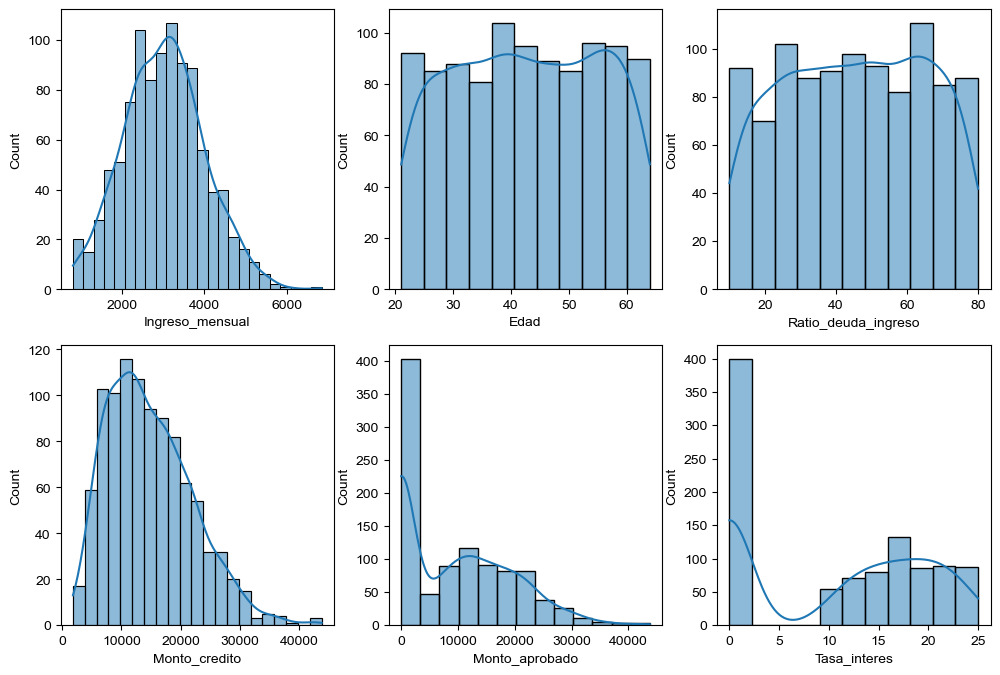

In [4]:
plt.clf()
fig, axs = plt.subplots(nrows= 2, ncols= 3, figsize= (12,8))
for i, variable in enumerate(['Ingreso_mensual', 'Edad', 'Ratio_deuda_ingreso', 'Monto_credito', 'Monto_aprobado', 'Tasa_interes']):
    ax = axs[i//3, i%3]
    sns.histplot(data=dataset[variable],ax=ax, kde= True)
sns.set_style('darkgrid')
plt.show()

<Figure size 640x480 with 0 Axes>

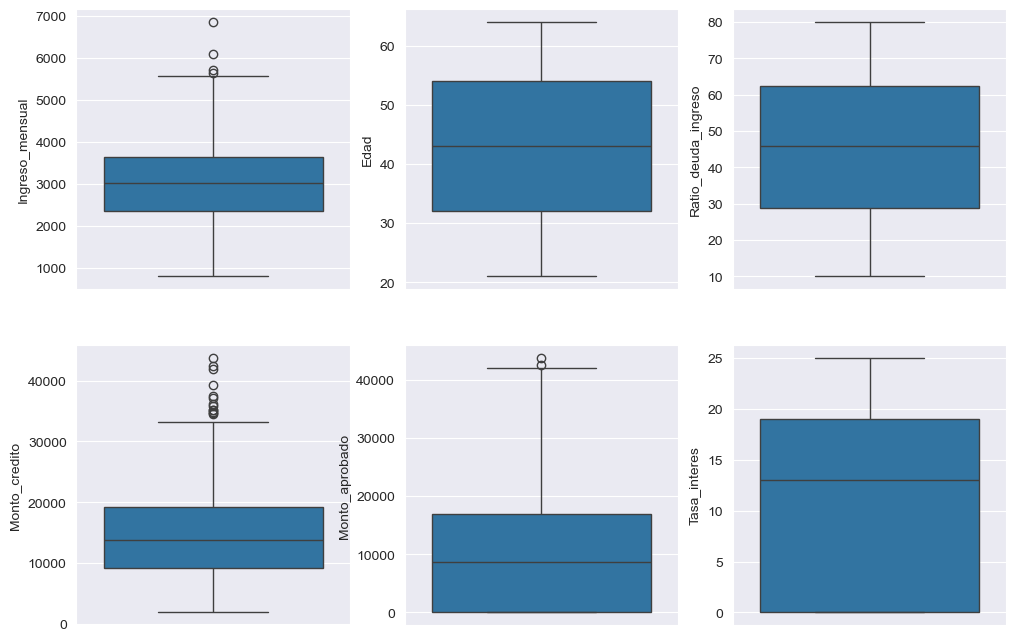

In [5]:
plt.clf()
fig, axs = plt.subplots(nrows= 2, ncols= 3, figsize= (12,8))
for i, variable in enumerate(['Ingreso_mensual', 'Edad', 'Ratio_deuda_ingreso', 'Monto_credito', 'Monto_aprobado', 'Tasa_interes']):
    ax = axs[i//3, i%3]
    sns.boxplot(data=dataset[variable],ax=ax)
sns.set_style('darkgrid')
plt.show()

C:\Users\osqui\AppData\Local\Temp\ipykernel_8604\1176227486.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x=variable, ax=ax, palette=['coral', 'lightblue'])
C:\Users\osqui\AppData\Local\Temp\ipykernel_8604\1176227486.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x=variable, ax=ax, palette=['coral', 'lightblue'])
C:\Users\osqui\AppData\Local\Temp\ipykernel_8604\1176227486.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_plot, x='Estado_credito_label', ax=ax, palette=['coral', 'ligh

<Figure size 640x480 with 0 Axes>

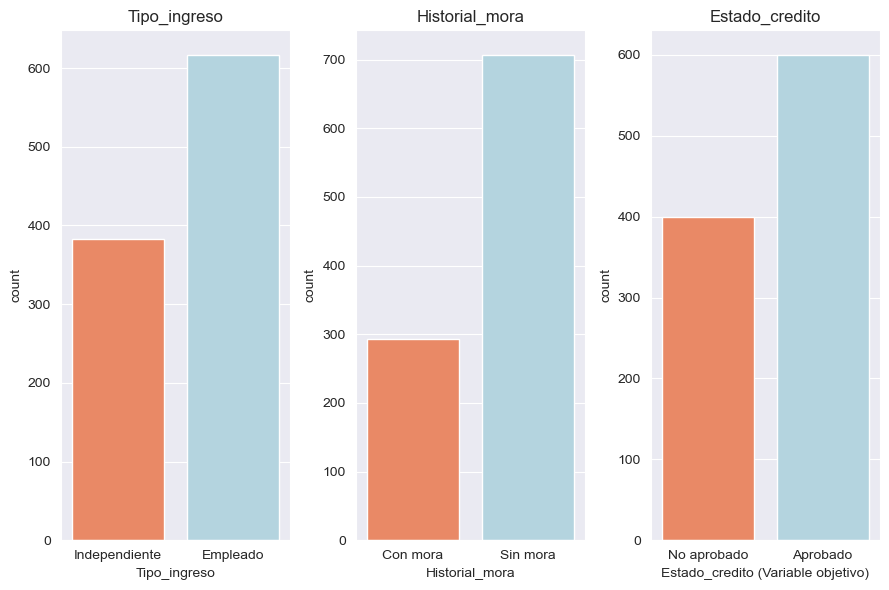

In [6]:
plt.clf()
fig, axs = plt.subplots(nrows= 1, ncols= 3, figsize= (9,6))

for i, variable in enumerate(['Tipo_ingreso', 'Historial_mora','Estado_credito']):
    ax = axs[i]
    
    if variable == 'Estado_credito':
        # Crear una versión mapeada para graficar
        data_plot = dataset.copy()
        data_plot['Estado_credito_label'] = data_plot['Estado_credito'].apply(lambda x: 'Aprobado' if x == 1 else 'No aprobado')
        sns.countplot(data=data_plot, x='Estado_credito_label', ax=ax, palette=['coral', 'lightblue'])
        ax.set_xlabel('Estado_credito (Variable objetivo)')
    else:
        sns.countplot(data=dataset, x=variable, ax=ax, palette=['coral', 'lightblue'])
    
    ax.set_title(variable)

plt.tight_layout()
sns.set_style('darkgrid')
plt.show()


## ***Preprocesamiento de datos***

In [7]:
for variable in ['Tipo_ingreso','Historial_mora','Estado_credito']:
    print(f'Valores {variable}: {dataset[variable].drop_duplicates().tolist()}\n')


Valores Tipo_ingreso: ['Independiente', 'Empleado']

Valores Historial_mora: ['Con mora', 'Sin mora']

Valores Estado_credito: [False, True]



In [8]:
#Transformación Tipo de ingreso
dataset['Tipo_ingreso'] =np.where(dataset['Tipo_ingreso'] == 'Independiente', 0, 1)

#Transformación Historial de mora
dataset['Historial_mora'] =np.where(dataset['Historial_mora'] == 'Con mora', 0, 1)

#Transformación Estado de credito
dataset['Estado_credito'] = dataset['Estado_credito'].astype(int)

#Transformamos tasa de interes
dataset['Tasa_interes'] = dataset['Tasa_interes'] / 100

for variable in ['Tipo_ingreso','Historial_mora','Estado_credito']:
    print(f'Valores {variable}: {dataset[variable].drop_duplicates().tolist()}\n')
print(f'Valores Tasa interes: {dataset['Tasa_interes'].drop_duplicates().tolist()}')

Valores Tipo_ingreso: [0, 1]

Valores Historial_mora: [0, 1]

Valores Estado_credito: [0, 1]

Valores Tasa interes: [0.0, 0.2, 0.11, 0.14, 0.21, 0.22, 0.12, 0.17, 0.19, 0.13, 0.15, 0.18, 0.24, 0.23, 0.16, 0.1, 0.25]


### ***Data Leakage***

C:\Users\osqui\AppData\Local\Temp\ipykernel_8604\2935933299.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 640x480 with 0 Axes>

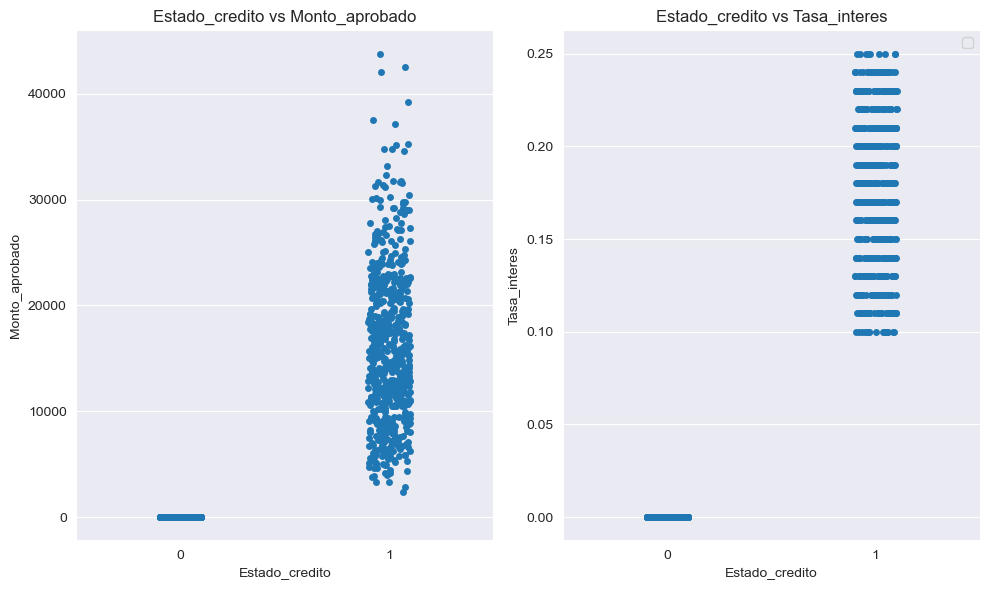

In [9]:
plt.clf()
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,6))
for i, variable in enumerate(['Monto_aprobado', 'Tasa_interes']):
    ax = axs[i]
    sns.stripplot(x='Estado_credito', y=variable , ax=ax, data= dataset)
    ax.set_title(f'Estado_credito vs {variable}')
plt.tight_layout()
plt.legend()
sns.set_style('darkgrid')
plt.show()

### ***Partición de datos (parte 3)***

In [10]:
X = dataset.drop(['Estado_credito', 'Monto_aprobado', 'Tasa_interes'], axis = 1)
Y = dataset['Estado_credito']
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state= 0)

### ***Ajuste del modelo***

In [11]:
modelo = DecisionTreeClassifier(criterion= 'entropy', max_depth=2).fit(X_train, y_train)

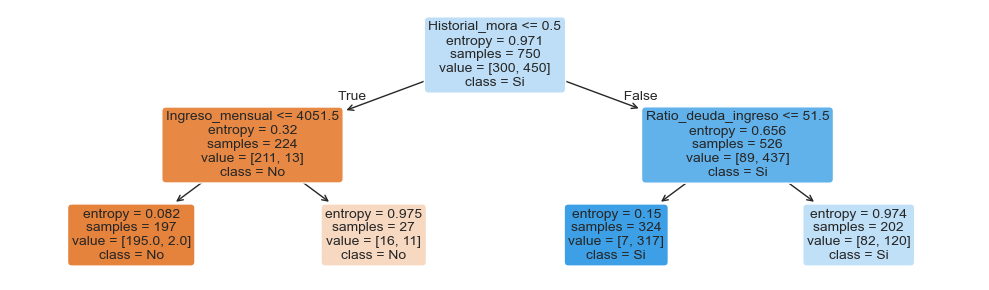

In [12]:
plt.figure(figsize=(10,3))
plot_tree(modelo, 
          feature_names=X.columns, 
          class_names=['No', 'Si'],
          filled=True,        
          rounded=True,  
          fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\osqui\AppData\Local\Temp\ipykernel_8604\2490441841.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')


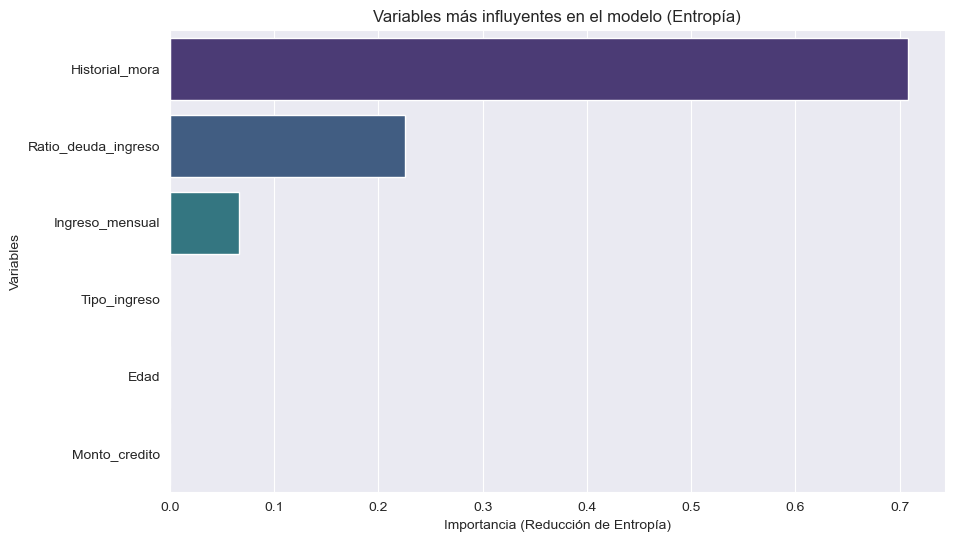

In [13]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 2. Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')

plt.title('Variables más influyentes en el modelo (Entropía)')
plt.xlabel('Importancia (Reducción de Entropía)')
plt.ylabel('Variables')
plt.show()

## ***Evaluación***

In [14]:
prediccion_test = modelo.predict(X_test)

evaluation = pd.DataFrame(columns=['SCORE'], data=[accuracy_score(y_test, prediccion_test),
                                                   recall_score(y_test, prediccion_test), 
                                                   precision_score(y_test, prediccion_test)],
                                            index=['ACCURACY', 'RECALL', 'PRECISION']).round(2)
evaluation


,SCORE
ACCURACY,0.81
RECALL,0.95
PRECISION,0.78


## ***Matriz de Confusión***

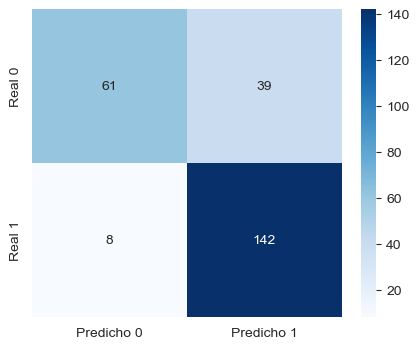

In [15]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, prediccion_test), annot=True, cmap='Blues', fmt='d',
                xticklabels=['Predicho 0', 'Predicho 1'],
                yticklabels=['Real 0', 'Real 1'])
plt.show()